# Trabalho 07 – Reconhecimento de Dígitos com Perceptron Multicamadas

**Disciplina:** EL056 – Redes Neurais Artificiais (PPGEELT/UFU)
**Professor:** Prof. Dr. Keiji Yamanaka
**Aluno:** Lucas Albino Martins (12622EEL006)

**Enunciado.** Treinar uma MLP para reconhecer dígitos, construindo uma base de dados para o treinamento com dígitos de cinco fontes diferentes.

Este notebook tem o mesmo código do programa `trabalho07_digitos.py` (as células de código são extraídas diretamente dele), intercalado com a teoria e a discussão dos resultados. Execute-o a partir da pasta `trabalho07/`, que contém a subpasta `fontes/`.

## 1. Configuração

Todos os parâmetros ficam concentrados aqui: fontes (com alternativas caso algum arquivo não exista), tamanho da grade, limiar de binarização, hiperparâmetros da rede e dos experimentos. A pasta `fontes/` do projeto é consultada primeiro, o que torna a base idêntica em qualquer sistema operacional.

In [1]:
import argparse
import json
import os
import sys
import time
import warnings

import numpy as np
from PIL import Image, ImageDraw, ImageFont

import matplotlib
matplotlib.use("Agg")                      # gera figuras sem abrir janelas
import matplotlib.pyplot as plt

# =====================================================================
# CONFIGURAÇÃO GERAL (altere aqui)
# =====================================================================

PASTA_SCRIPT = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

# ---- Fontes: (rótulo, [arquivos candidatos em ordem de preferência]) ----
# O primeiro arquivo encontrado é usado. Se o preferido não existir, o
# programa avisa e usa a próxima alternativa da lista. Para usar outra
# fonte basta colocar o caminho completo (ou só o nome do .ttf) no início
# da lista correspondente.
FONTES = [
    ("Sem serifa negrito (DejaVu Sans Bold)",
     ["DejaVuSans-Bold.ttf", "LiberationSans-Bold.ttf", "arialbd.ttf", "Arial Bold.ttf"]),
    ("Serifada regular (Liberation Serif)",
     ["LiberationSerif-Regular.ttf", "times.ttf", "Times New Roman.ttf", "DejaVuSerif.ttf"]),
    ("Sem serifa fina (DejaVu Sans ExtraLight)",
     ["DejaVuSans-ExtraLight.ttf", "Poppins-Light.ttf", "segoeuil.ttf", "LiberationSans-Regular.ttf"]),
    ("Manuscrita/cursiva (Kalam)",
     ["Kalam-Regular.ttf", "segoepr.ttf", "LiberationSerif-Italic.ttf", "DejaVuSerif-Italic.ttf"]),
    ("Serifada condensada (DejaVu Serif Condensed)",
     ["DejaVuSerifCondensed.ttf", "DejaVuSerif.ttf", "georgia.ttf", "LiberationSerif-Regular.ttf"]),
]

# Pastas onde os arquivos de fonte são procurados (a pasta fontes/ do
# projeto vem primeiro, garantindo reprodutibilidade em qualquer sistema).
PASTAS_FONTES = [
    os.path.join(PASTA_SCRIPT, "fontes"),
    "/usr/share/fonts",
    "/usr/local/share/fonts",
    os.path.expanduser("~/.fonts"),
    os.path.expanduser("~/.local/share/fonts"),
    "/Library/Fonts",
    "/System/Library/Fonts",
    os.path.expanduser("~/Library/Fonts"),
    "C:/Windows/Fonts",
]

DIGITOS = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "0"]   # ordem do enunciado
LINHAS, COLUNAS = 12, 9          # grade de pixels de cada padrão (12 x 9 = 108 entradas)
TAMANHO_FONTE = 200              # tamanho (pt) usado na renderização em alta resolução
LIMIAR = 0.30                    # fração mínima de tinta para o pixel virar +1

# ---- Hiperparâmetros da MLP ----
N_OCULTOS = 20                   # neurônios na camada oculta
ALFA = 0.01                      # taxa de aprendizagem
MOMENTO = 0.8                    # termo de momento (0 desativa)
TOLERANCIA = 0.05                # erro quadrático total de parada
MAX_EPOCAS = 5000                # limite de épocas
AMPLITUDE_PESOS = 0.1            # pesos iniciais ~ U(-A, +A); com 108 entradas,
                                 # A = 0.5 satura a tanh logo no início do treino
SEMENTE = 2026                   # semente global (reprodutibilidade)

# ---- Experimentos ----
NIVEIS_RUIDO = [0.0, 0.05, 0.10, 0.15, 0.20]     # fração de pixels invertidos
REPETICOES_RUIDO = 30                             # repetições por nível
OCULTOS_SENSIBILIDADE = [5, 10, 20, 40]           # estudo de sensibilidade
SEMENTES_SENSIBILIDADE = 5                        # inicializações por configuração
SEMENTES_LOFO = 5                                 # inicializações no leave-one-font-out

# Cores das figuras (tons sóbrios, adequados à impressão)
COR_PRINCIPAL = "#2a78d6"
COR_SECUNDARIA = "#eb6834"
COR_TEXTO = "#52514e"


## 2. Construção da base de dados

Cada dígito é desenhado em alta resolução com `ImageFont.truetype`, recortado pela caixa delimitadora da tinta e centralizado numa tela com a mesma proporção da grade (12×9), preservando a proporção do caractere. A redução para 12×9 usa média de área (filtro *box*), de modo que cada pixel final vale a fração de tinta da região correspondente; pixels com fração $\geq 0{,}30$ recebem $+1$ e os demais $-1$ (representação bipolar). O vetor de entrada tem, portanto, $n = 108$ componentes.

As saídas desejadas usam codificação bipolar *one-hot*: $t_k = +1$ para a classe correta e $t_k = -1$ para as outras nove.

O ruído é gerado invertendo o sinal de exatamente $\lfloor p\,n \rceil$ pixels escolhidos aleatoriamente em cada padrão ($p$ = 5, 10, 15 e 20%).

In [2]:
# =====================================================================
# 1. CONSTRUÇÃO DA BASE DE DADOS
# =====================================================================

def _indexar_pastas(pastas):
    """Percorre as pastas de fontes uma única vez e devolve {nome_minúsculo: caminho}."""
    indice = {}
    for pasta in pastas:
        if not os.path.isdir(pasta):
            continue
        for raiz, _, arquivos in os.walk(pasta):
            for arq in arquivos:
                if arq.lower().endswith((".ttf", ".otf")):
                    indice.setdefault(arq.lower(), os.path.join(raiz, arq))
    return indice


def localizar_fontes(fontes=FONTES, pastas=PASTAS_FONTES, tamanho=TAMANHO_FONTE):
    """Carrega as fontes configuradas, com aviso e alternativa quando faltarem.

    Retorna uma lista de tuplas (rótulo, caminho_usado, objeto ImageFont).
    """
    indice = _indexar_pastas(pastas)
    carregadas = []
    for rotulo, candidatos in fontes:
        caminho = None
        for i, cand in enumerate(candidatos):
            achado = cand if os.path.isfile(cand) else indice.get(os.path.basename(cand).lower())
            if achado:
                caminho = achado
                if i > 0:
                    warnings.warn(f"Fonte preferida '{candidatos[0]}' não encontrada para "
                                  f"'{rotulo}'; usando alternativa '{cand}'.")
                break
        if caminho is None:
            warnings.warn(f"Nenhuma fonte encontrada para '{rotulo}'; usando a fonte "
                          "padrão do Pillow (o resultado pode ficar diferente).")
            fonte = ImageFont.load_default(size=tamanho)
            caminho = "<padrão do Pillow>"
        else:
            fonte = ImageFont.truetype(caminho, tamanho)
        carregadas.append((rotulo, caminho, fonte))
    return carregadas


def renderizar_digito(fonte, digito, linhas=LINHAS, colunas=COLUNAS, limiar=LIMIAR):
    """Renderiza um dígito e o converte em uma matriz bipolar linhas x colunas.

    Passos: desenho em alta resolução -> recorte pela caixa delimitadora ->
    centralização numa tela com a proporção da grade (mantendo a proporção
    do dígito) -> redução por média de área -> binarização -> bipolar.
    """
    lado = 3 * TAMANHO_FONTE
    img = Image.new("L", (lado, lado), 0)                    # fundo 0, tinta 255
    ImageDraw.Draw(img).text((lado // 3, lado // 6), digito, font=fonte, fill=255)
    caixa = img.getbbox()                                    # caixa delimitadora da tinta
    recorte = img.crop(caixa)
    w, h = recorte.size

    # Tela com a mesma proporção da grade, grande o bastante para o dígito
    proporcao = colunas / linhas
    alt = max(h, int(np.ceil(w / proporcao)))
    larg = int(round(alt * proporcao))
    tela = Image.new("L", (larg, alt), 0)
    tela.paste(recorte, ((larg - w) // 2, (alt - h) // 2))

    # Redução por média de área (BOX): cada pixel final = fração de tinta
    reduzida = np.asarray(tela.resize((colunas, linhas), Image.BOX), dtype=float) / 255.0
    binaria = reduzida >= limiar
    return np.where(binaria, 1, -1).astype(np.int8)


def construir_base(fontes_carregadas, digitos=DIGITOS):
    """Monta a base completa: X (50 x 108) bipolar, rótulos (0-9) e índice da fonte."""
    X, y, id_fonte = [], [], []
    for f, (_, _, fonte) in enumerate(fontes_carregadas):
        for d in digitos:
            X.append(renderizar_digito(fonte, d).ravel())
            y.append(int(d))
            id_fonte.append(f)
    return np.array(X, dtype=float), np.array(y), np.array(id_fonte)


def adicionar_ruido(X, fracao, rng):
    """Inverte o sinal de uma fração exata dos pixels de cada padrão (ruído)."""
    Xr = X.copy()
    n = X.shape[1]
    k = int(round(fracao * n))
    for i in range(X.shape[0]):
        idx = rng.choice(n, size=k, replace=False)
        Xr[i, idx] *= -1
    return Xr


def codificar_alvos(y, n_classes=10):
    """Codificação bipolar one-hot: +1 na classe correta, -1 nas demais."""
    T = -np.ones((len(y), n_classes))
    T[np.arange(len(y)), y] = 1.0
    return T


## 3. Perceptron multicamadas e *backpropagation*

A rede tem $n = 108$ entradas $x_i$, uma camada oculta com $p$ neurônios $z_j$ e $m = 10$ saídas $y_k$. Com a notação de Fausett (1994), sendo $v_{0j}$ e $w_{0k}$ os bias:

$$z\_in_j = v_{0j} + \sum_{i=1}^{n} x_i v_{ij}, \qquad z_j = f(z\_in_j)$$
$$y\_in_k = w_{0k} + \sum_{j=1}^{p} z_j w_{jk}, \qquad y_k = f(y\_in_k)$$

A ativação é a tangente hiperbólica (sigmoide bipolar), cuja derivada pode ser escrita a partir da própria saída:

$$f(x) = \tanh(x), \qquad f'(x) = 1 - f(x)^2 .$$

O erro quadrático de um padrão é $E = \tfrac12 \sum_k (t_k - y_k)^2$. A regra delta generalizada (Rumelhart; Hinton; Williams, 1986) retropropaga os termos de erro:

$$\delta_k = (t_k - y_k)\, f'(y\_in_k), \qquad \delta_j = f'(z\_in_j) \sum_{k=1}^{m} \delta_k\, w_{jk}.$$

As correções, com taxa de aprendizagem $\alpha$ e momento $\mu$, são

$$\Delta w_{jk}(t) = \alpha\, \delta_k\, z_j + \mu\, \Delta w_{jk}(t-1), \qquad \Delta v_{ij}(t) = \alpha\, \delta_j\, x_i + \mu\, \Delta v_{ij}(t-1),$$

com $z_0 = x_0 = 1$ para os bias. O treinamento é padrão a padrão (*online*), com ordem aleatória a cada época, e para quando o erro quadrático total da época

$$E_{\text{total}} = \tfrac12 \sum_{p} \sum_{k} (t_{pk} - y_{pk})^2$$

fica abaixo da tolerância ou quando se atinge o número máximo de épocas. A classe atribuída é a do neurônio de saída com maior valor.

**Inicialização.** Os pesos são sorteados em $U(-0{,}1;\,0{,}1)$ com semente fixa. Com 108 entradas bipolares, a amplitude 0,5 (comum em exemplos com poucas entradas) produz $z\_in_j$ com desvio padrão próximo de 3, o que satura a $\tanh$ ($f' \approx 0$) e trava o aprendizado — foi o que se observou num primeiro ensaio.

In [3]:
# =====================================================================
# 2. REDE MLP (implementação própria em NumPy)
# =====================================================================

class MLP:
    """Perceptron multicamadas com uma camada oculta e ativação tanh.

    V : pesos entrada -> oculta, forma (n_entradas + 1, n_ocultos); linha 0 = bias
    W : pesos oculta -> saída,   forma (n_ocultos + 1, n_saidas);  linha 0 = bias
    """

    def __init__(self, n_entradas, n_ocultos, n_saidas, semente=SEMENTE,
                 amplitude=AMPLITUDE_PESOS):
        rng = np.random.default_rng(semente)
        self.V = rng.uniform(-amplitude, amplitude, (n_entradas + 1, n_ocultos))
        self.W = rng.uniform(-amplitude, amplitude, (n_ocultos + 1, n_saidas))
        self.rng = rng

    @staticmethod
    def f(x):
        """Função de ativação: tangente hiperbólica (sigmoide bipolar)."""
        return np.tanh(x)

    @staticmethod
    def df(fx):
        """Derivada da tanh escrita em função da própria saída: 1 - f(x)^2."""
        return 1.0 - fx ** 2

    def propagar(self, X):
        """Fase direta. Aceita um padrão (vetor) ou vários (matriz)."""
        Z = self.f(X @ self.V[1:] + self.V[0])      # saídas da camada oculta
        Y = self.f(Z @ self.W[1:] + self.W[0])      # saídas da rede
        return Z, Y

    def erro_total(self, X, T):
        """Erro quadrático total: E = 1/2 * soma_p soma_k (t_pk - y_pk)^2."""
        _, Y = self.propagar(X)
        return 0.5 * float(np.sum((T - Y) ** 2))

    def treinar(self, X, T, alfa=ALFA, momento=MOMENTO, tolerancia=TOLERANCIA,
                max_epocas=MAX_EPOCAS, verboso=False):
        """Backpropagation padrão a padrão (online), com momento.

        Parada: E < tolerância ou número máximo de épocas.
        Retorna a lista com o erro quadrático total ao fim de cada época.
        """
        dV_ant = np.zeros_like(self.V)
        dW_ant = np.zeros_like(self.W)
        historico = []
        for epoca in range(1, max_epocas + 1):
            for p in self.rng.permutation(len(X)):         # ordem aleatória a cada época
                x, t = X[p], T[p]
                # --- fase direta ---
                z, yv = self.propagar(x)
                # --- retropropagação do erro ---
                delta_k = (t - yv) * self.df(yv)               # termos de erro da saída
                delta_j = (self.W[1:] @ delta_k) * self.df(z)  # termos de erro da oculta
                # --- correções (gradiente + momento) ---
                dW = alfa * np.outer(np.concatenate(([1.0], z)), delta_k) + momento * dW_ant
                dV = alfa * np.outer(np.concatenate(([1.0], x)), delta_j) + momento * dV_ant
                self.W += dW
                self.V += dV
                dW_ant, dV_ant = dW, dV
            E = self.erro_total(X, T)
            historico.append(E)
            if verboso and (epoca % 100 == 0 or E < tolerancia):
                print(f"  época {epoca:5d}  E = {E:.5f}")
            if E < tolerancia:
                break
        return historico

    def classificar(self, X):
        """Classe = índice do neurônio de saída com maior valor."""
        _, Y = self.propagar(X)
        return np.argmax(np.atleast_2d(Y), axis=1)


def acuracia(rede, X, y):
    return float(np.mean(rede.classificar(X) == y))


def treinar_rede(X, y, n_ocultos=N_OCULTOS, semente=SEMENTE, verboso=False):
    """Cria e treina uma MLP; devolve (rede, histórico de erro)."""
    rede = MLP(X.shape[1], n_ocultos, 10, semente=semente)
    hist = rede.treinar(X, codificar_alvos(y), verboso=verboso)
    return rede, hist


## 4. Experimentos

1. Treino com os 50 padrões e curva de $E_{\text{total}}$ por época (e o mesmo treino sem momento, para comparação);
2. acurácia de treino e matriz de confusão (também sob 20% de ruído, acumulada em 30 repetições);
3. robustez a ruído: acurácia média de 30 repetições por nível;
4. generalização entre fontes (*leave-one-font-out*): treino com 4 fontes e teste na quinta, com 5 inicializações;
5. sensibilidade ao número de neurônios ocultos (5, 10, 20, 40), com 5 inicializações cada.

In [4]:
# =====================================================================
# 3. EXPERIMENTOS
# =====================================================================

def matriz_confusao(y_real, y_prev, n=10):
    M = np.zeros((n, n), dtype=int)
    for r, p in zip(y_real, y_prev):
        M[r, p] += 1
    return M


def teste_ruido(rede, X, y, niveis=NIVEIS_RUIDO, repeticoes=REPETICOES_RUIDO, semente=SEMENTE):
    """Acurácia média (e desvio) para cada nível de ruído."""
    rng = np.random.default_rng(semente + 1)
    medias, desvios = [], []
    for nivel in niveis:
        accs = [acuracia(rede, adicionar_ruido(X, nivel, rng), y) for _ in range(repeticoes)]
        medias.append(float(np.mean(accs)))
        desvios.append(float(np.std(accs)))
    return medias, desvios


def leave_one_font_out(X, y, id_fonte, rotulos, n_sementes=SEMENTES_LOFO):
    """Treina com 4 fontes e testa na quinta, para as 5 combinações."""
    resultados = []
    for f in range(len(rotulos)):
        treino, teste = id_fonte != f, id_fonte == f
        accs, epocas, erros_sem0 = [], [], None
        for s in range(n_sementes):
            rede, hist = treinar_rede(X[treino], y[treino], semente=SEMENTE + s)
            prev = rede.classificar(X[teste])
            accs.append(float(np.mean(prev == y[teste])))
            epocas.append(len(hist))
            if s == 0:
                erros_sem0 = [f"{r}->{p}" for r, p in zip(y[teste], prev) if r != p]
        resultados.append({
            "fonte_teste": rotulos[f],
            "acuracia_media": float(np.mean(accs)),
            "acuracia_desvio": float(np.std(accs)),
            "acuracias": accs,
            "epocas_media": float(np.mean(epocas)),
            "erros_semente_principal": erros_sem0,
        })
    return resultados


def sensibilidade_ocultos(X, y, lista=OCULTOS_SENSIBILIDADE, n_sementes=SEMENTES_SENSIBILIDADE):
    """Varia o nº de neurônios ocultos: épocas até convergir e acurácia com 10% de ruído."""
    saida = []
    for n in lista:
        epocas, convergiu, acc_treino, acc_r10 = [], [], [], []
        for s in range(n_sementes):
            rede, hist = treinar_rede(X, y, n_ocultos=n, semente=SEMENTE + s)
            epocas.append(len(hist))
            convergiu.append(hist[-1] < TOLERANCIA)
            acc_treino.append(acuracia(rede, X, y))
            m, _ = teste_ruido(rede, X, y, niveis=[0.10], semente=SEMENTE + 100 + s)
            acc_r10.append(m[0])
        saida.append({
            "n_ocultos": n,
            "epocas_media": float(np.mean(epocas)),
            "epocas_desvio": float(np.std(epocas)),
            "epocas": epocas,
            "convergiu": int(sum(convergiu)),
            "acuracia_treino_media": float(np.mean(acc_treino)),
            "acuracia_ruido10_media": float(np.mean(acc_r10)),
            "acuracia_ruido10_desvio": float(np.std(acc_r10)),
        })
    return saida


## 5. Funções de gráficos

In [5]:
# =====================================================================
# 4. GRÁFICOS
# =====================================================================

def _estilo():
    plt.rcParams.update({
        "font.size": 10, "axes.edgecolor": COR_TEXTO, "axes.labelcolor": "#0b0b0b",
        "xtick.color": COR_TEXTO, "ytick.color": COR_TEXTO,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
        "savefig.dpi": 200, "savefig.bbox": "tight",
    })


def fig_base(X, rotulos, caminho, titulo=None):
    """Grade 5 x 10 com todos os padrões binarizados (preto = +1)."""
    n_f = len(rotulos)
    fig, eixos = plt.subplots(n_f, len(DIGITOS), figsize=(len(DIGITOS) * 0.75, n_f * 1.0))
    for i in range(n_f):
        for j in range(len(DIGITOS)):
            ax = eixos[i, j]
            ax.imshow(X[i * len(DIGITOS) + j].reshape(LINHAS, COLUNAS), cmap="gray_r",
                      vmin=-1, vmax=1, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for s in ax.spines.values():
                s.set_visible(True); s.set_color("#c3c2b7"); s.set_linewidth(0.5)
        eixos[i, 0].set_ylabel(f"F{i + 1}", rotation=0, labelpad=12, va="center")
    if titulo:
        fig.suptitle(titulo, fontsize=10)
    fig.tight_layout(pad=0.3)
    fig.savefig(caminho)
    plt.close(fig)


def fig_curva_erro(hist, caminho, tolerancia=TOLERANCIA):
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.plot(np.arange(1, len(hist) + 1), hist, color=COR_PRINCIPAL, lw=1.8)
    ax.axhline(tolerancia, color=COR_TEXTO, lw=1, ls="--")
    ax.text(1, tolerancia * 0.8, f"tolerância = {tolerancia}", ha="left",
            va="top", color=COR_TEXTO, fontsize=9)
    ax.set_yscale("log")
    ax.set_xlabel("Época")
    ax.set_ylabel("Erro quadrático total (escala log)")
    fig.savefig(caminho)
    plt.close(fig)


def fig_confusao(matrizes, titulos, caminho):
    """Uma ou mais matrizes de confusão lado a lado (linhas = classe real)."""
    fig, eixos = plt.subplots(1, len(matrizes), figsize=(4.3 * len(matrizes), 4.0))
    eixos = np.atleast_1d(eixos)
    for ax, M, tit in zip(eixos, matrizes, titulos):
        ax.imshow(M, cmap="Blues", vmin=0, vmax=max(1, M.max()))
        ax.grid(False)
        ax.set_xticks(range(10)); ax.set_yticks(range(10))
        ax.set_xlabel("Classe prevista"); ax.set_ylabel("Classe real")
        ax.set_title(tit, fontsize=10)
        for i in range(10):
            for j in range(10):
                if M[i, j]:
                    ax.text(j, i, M[i, j], ha="center", va="center", fontsize=7.5,
                            color="white" if M[i, j] > M.max() / 2 else "#0b0b0b")
    fig.tight_layout()
    fig.savefig(caminho)
    plt.close(fig)


def fig_ruido(niveis, medias, desvios, caminho):
    fig, ax = plt.subplots(figsize=(6, 3.4))
    pct = [100 * n for n in niveis]
    m, d = np.array(medias) * 100, np.array(desvios) * 100
    ax.fill_between(pct, m - d, np.minimum(m + d, 100), color=COR_PRINCIPAL, alpha=0.15, lw=0)
    ax.plot(pct, m, color=COR_PRINCIPAL, lw=1.8, marker="o", ms=6)
    for x, v in zip(pct, m):
        ax.text(x, v - 4, f"{v:.1f}%", ha="center", va="top", fontsize=8, color=COR_TEXTO)
    ax.set_xticks(pct)
    ax.set_ylim(max(0, m.min() - d.max() - 15), 102)
    ax.set_xlabel("Pixels invertidos (%)")
    ax.set_ylabel("Acurácia (%)")
    fig.savefig(caminho)
    plt.close(fig)


## 6. Execução completa

A função `main` executa todos os passos, salva as figuras e o arquivo `figuras/resultados.json`.

In [6]:
# =====================================================================
# 5. PROGRAMA PRINCIPAL
# =====================================================================

def main(pasta_saida=None):
    _estilo()
    pasta = pasta_saida or os.path.join(PASTA_SCRIPT, "figuras")
    os.makedirs(pasta, exist_ok=True)
    t0 = time.time()

    # ---- 1. Base de dados ----
    print("[1] Construindo a base de dados ...")
    fontes = localizar_fontes()
    rotulos = [r for r, _, _ in fontes]
    for i, (r, c, _) in enumerate(fontes, 1):
        print(f"    F{i}: {r}  <- {os.path.basename(c)}")
    X, y, id_fonte = construir_base(fontes)
    print(f"    {X.shape[0]} padrões de {X.shape[1]} entradas ({LINHAS}x{COLUNAS})")

    rng = np.random.default_rng(SEMENTE)
    ruidosas = {f"X_ruido_{int(round(100 * n)):02d}": adicionar_ruido(X, n, rng)
                for n in NIVEIS_RUIDO if n > 0}
    np.savez(os.path.join(pasta, "base_digitos.npz"), X=X, y=y, id_fonte=id_fonte,
             fontes=np.array(rotulos), linhas=LINHAS, colunas=COLUNAS, **ruidosas)
    fig_base(X, rotulos, os.path.join(pasta, "fig_base_dados.png"))
    fig_base(ruidosas["X_ruido_10"], rotulos, os.path.join(pasta, "fig_base_ruido10.png"))

    # ---- 2/3.1 Treinamento principal ----
    print("[2] Treinando a MLP com os 50 padrões ...")
    rede, hist = treinar_rede(X, y, verboso=True)
    fig_curva_erro(hist, os.path.join(pasta, "fig_curva_erro.png"))

    # ---- 3.2 Acurácia de treino e matriz de confusão ----
    prev = rede.classificar(X)
    M = matriz_confusao(y, prev)
    acc_treino = float(np.mean(prev == y))
    print(f"    acurácia no treino = {100 * acc_treino:.1f}%")

    # Matriz de confusão acumulada sob 20% de ruído (onde a rede erra)
    rng_c = np.random.default_rng(SEMENTE + 3)
    M20 = sum(matriz_confusao(y, rede.classificar(adicionar_ruido(X, 0.20, rng_c)))
              for _ in range(REPETICOES_RUIDO))
    fig_confusao([M, M20], ["Treino (sem ruído)",
                            f"20% de ruído ({REPETICOES_RUIDO} repetições)"],
                 os.path.join(pasta, "fig_confusao.png"))

    # ---- 3.3 Robustez a ruído ----
    print("[3] Teste de robustez a ruído ...")
    medias, desvios = teste_ruido(rede, X, y)
    for n, m, d in zip(NIVEIS_RUIDO, medias, desvios):
        print(f"    ruído {100 * n:4.0f}%: acurácia = {100 * m:5.1f}% (dp {100 * d:.1f})")
    fig_ruido(NIVEIS_RUIDO, medias, desvios, os.path.join(pasta, "fig_ruido.png"))

    # Acurácia por fonte com 10% de ruído (diagnóstico adicional)
    rng_f = np.random.default_rng(SEMENTE + 7)
    acc_fonte_r10 = []
    for f in range(len(rotulos)):
        s = id_fonte == f
        acc_fonte_r10.append(float(np.mean([acuracia(rede, adicionar_ruido(X[s], 0.10, rng_f), y[s])
                                            for _ in range(REPETICOES_RUIDO)])))

    # Comparação: mesmo treino sem o termo de momento
    rede_sm = MLP(X.shape[1], N_OCULTOS, 10, semente=SEMENTE)
    hist_sm = rede_sm.treinar(X, codificar_alvos(y), momento=0.0)
    print(f"    sem momento: {len(hist_sm)} épocas (com momento: {len(hist)})")

    # ---- 3.4 Leave-one-font-out ----
    print("[4] Generalização entre fontes (leave-one-font-out) ...")
    lofo = leave_one_font_out(X, y, id_fonte, rotulos)
    for r in lofo:
        print(f"    teste em {r['fonte_teste']:<45s} acurácia = {100 * r['acuracia_media']:.1f}%")

    # ---- 3.5 Sensibilidade ao nº de neurônios ocultos ----
    print("[5] Sensibilidade ao número de neurônios ocultos ...")
    sens = sensibilidade_ocultos(X, y)
    for r in sens:
        print(f"    {r['n_ocultos']:3d} ocultos: {r['epocas_media']:7.1f} épocas, "
              f"acurácia (10% ruído) = {100 * r['acuracia_ruido10_media']:.1f}%")

    # ---- Salvar resultados ----
    resultados = {
        "configuracao": {
            "fontes": [{"rotulo": r, "arquivo": os.path.basename(c)} for r, c, _ in fontes],
            "grade": [LINHAS, COLUNAS], "n_entradas": int(X.shape[1]), "n_padroes": int(X.shape[0]),
            "limiar_binarizacao": LIMIAR, "n_ocultos": N_OCULTOS, "alfa": ALFA,
            "momento": MOMENTO, "tolerancia": TOLERANCIA, "max_epocas": MAX_EPOCAS,
            "amplitude_pesos": AMPLITUDE_PESOS, "semente": SEMENTE,
            "niveis_ruido": NIVEIS_RUIDO, "repeticoes_ruido": REPETICOES_RUIDO,
        },
        "base": {
            "pixels_ativos_media_por_fonte": [float(np.mean(np.sum(X[id_fonte == f] > 0, axis=1)))
                                              for f in range(len(rotulos))],
        },
        "treino": {
            "epocas": len(hist), "erro_inicial": hist[0], "erro_final": hist[-1],
            "convergiu": bool(hist[-1] < TOLERANCIA), "acuracia": acc_treino,
            "epocas_sem_momento": len(hist_sm), "acuracia_sem_momento": acuracia(rede_sm, X, y),
            "matriz_confusao": M.tolist(),
            "matriz_confusao_ruido20": M20.tolist(),
        },
        "ruido": {"niveis": NIVEIS_RUIDO, "acuracia_media": medias, "acuracia_desvio": desvios,
                  "acuracia_por_fonte_ruido10": acc_fonte_r10},
        "leave_one_font_out": lofo,
        "leave_one_font_out_media_geral": float(np.mean([r["acuracia_media"] for r in lofo])),
        "sensibilidade_ocultos": sens,
        "tempo_execucao_s": round(time.time() - t0, 1),
    }
    with open(os.path.join(pasta, "resultados.json"), "w", encoding="utf-8") as fp:
        json.dump(resultados, fp, ensure_ascii=False, indent=2)
    print(f"Concluído em {resultados['tempo_execucao_s']} s. Saídas em: {pasta}")
    return resultados


In [7]:
resultados = main()

[1] Construindo a base de dados ...
    F1: Sem serifa negrito (DejaVu Sans Bold)  <- DejaVuSans-Bold.ttf
    F2: Serifada regular (Liberation Serif)  <- LiberationSerif-Regular.ttf
    F3: Sem serifa fina (DejaVu Sans ExtraLight)  <- DejaVuSans-ExtraLight.ttf
    F4: Manuscrita/cursiva (Kalam)  <- Kalam-Regular.ttf
    F5: Serifada condensada (DejaVu Serif Condensed)  <- DejaVuSerifCondensed.ttf
    50 padrões de 108 entradas (12x9)


[2] Treinando a MLP com os 50 padrões ...
  época   100  E = 0.07355


  época   144  E = 0.04975


    acurácia no treino = 100.0%


[3] Teste de robustez a ruído ...
    ruído    0%: acurácia = 100.0% (dp 0.0)
    ruído    5%: acurácia = 100.0% (dp 0.0)
    ruído   10%: acurácia = 100.0% (dp 0.0)
    ruído   15%: acurácia =  98.9% (dp 1.3)
    ruído   20%: acurácia =  94.5% (dp 3.5)


    sem momento: 663 épocas (com momento: 144)
[4] Generalização entre fontes (leave-one-font-out) ...


    teste em Sem serifa negrito (DejaVu Sans Bold)         acurácia = 94.0%
    teste em Serifada regular (Liberation Serif)           acurácia = 100.0%
    teste em Sem serifa fina (DejaVu Sans ExtraLight)      acurácia = 100.0%
    teste em Manuscrita/cursiva (Kalam)                    acurácia = 62.0%
    teste em Serifada condensada (DejaVu Serif Condensed)  acurácia = 100.0%
[5] Sensibilidade ao número de neurônios ocultos ...


      5 ocultos:  3469.0 épocas, acurácia (10% ruído) = 85.0%
     10 ocultos:   330.6 épocas, acurácia (10% ruído) = 99.2%
     20 ocultos:   144.6 épocas, acurácia (10% ruído) = 99.9%
     40 ocultos:    81.4 épocas, acurácia (10% ruído) = 99.9%
Concluído em 36.2 s. Saídas em: /home/claude/trabalho07/figuras


### 6.1 Base de dados (linhas F1–F5 = fontes; preto = +1)

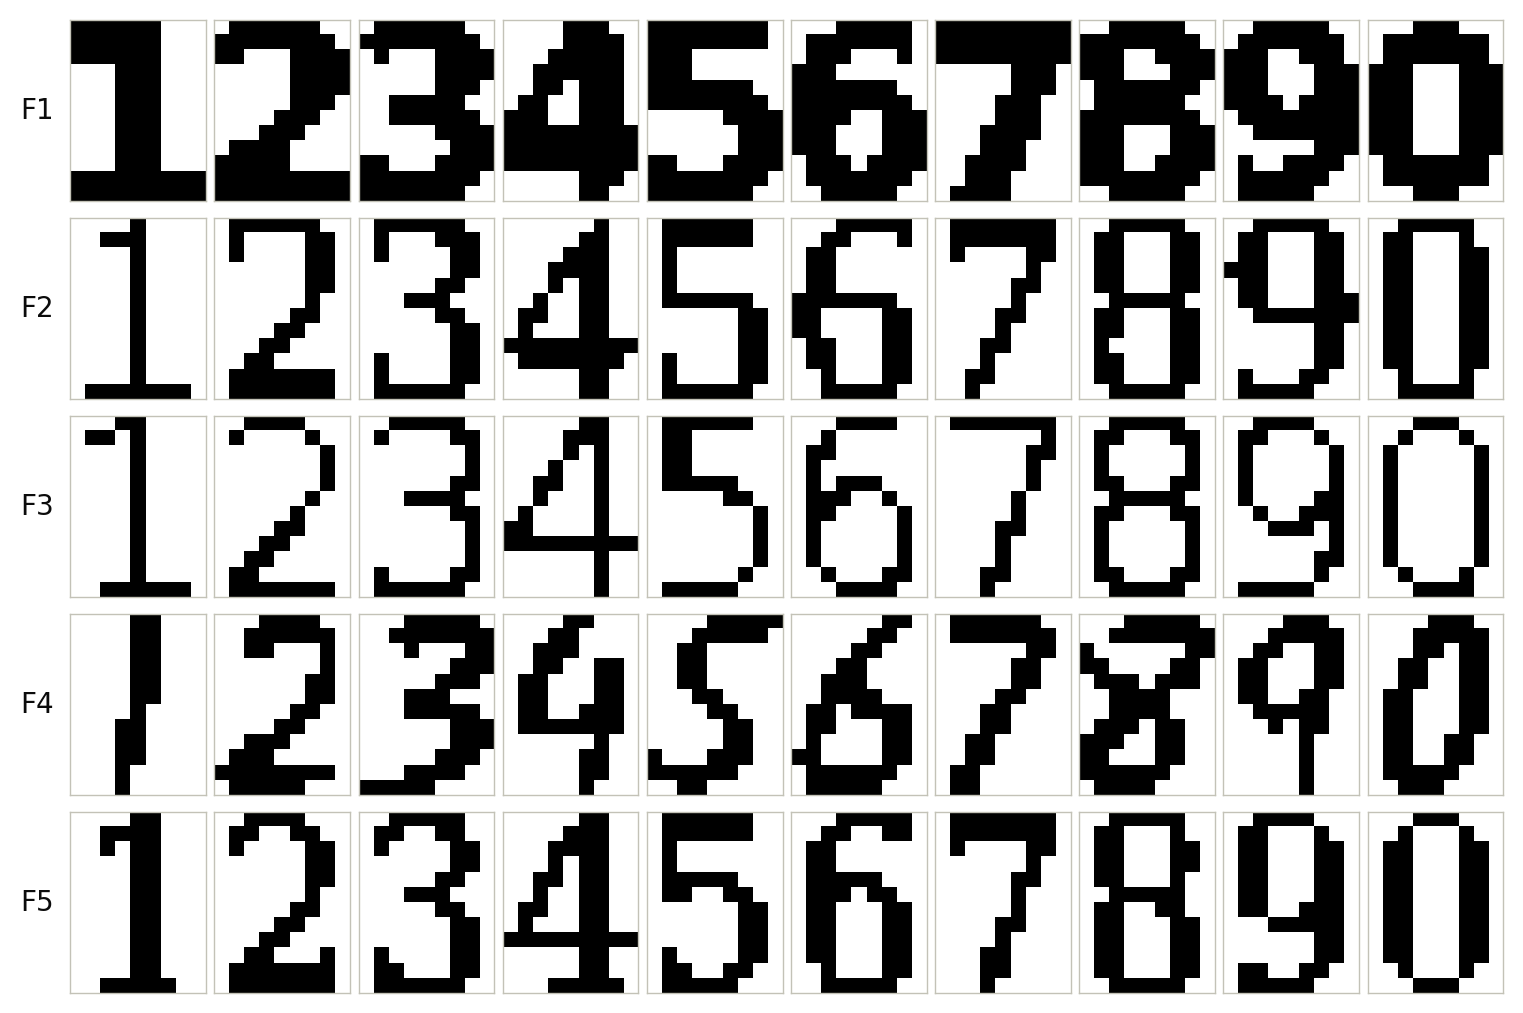

In [8]:
from IPython.display import Image, display
display(Image("figuras/fig_base_dados.png", width=700))

Exemplo da mesma base com 10% dos pixels invertidos:

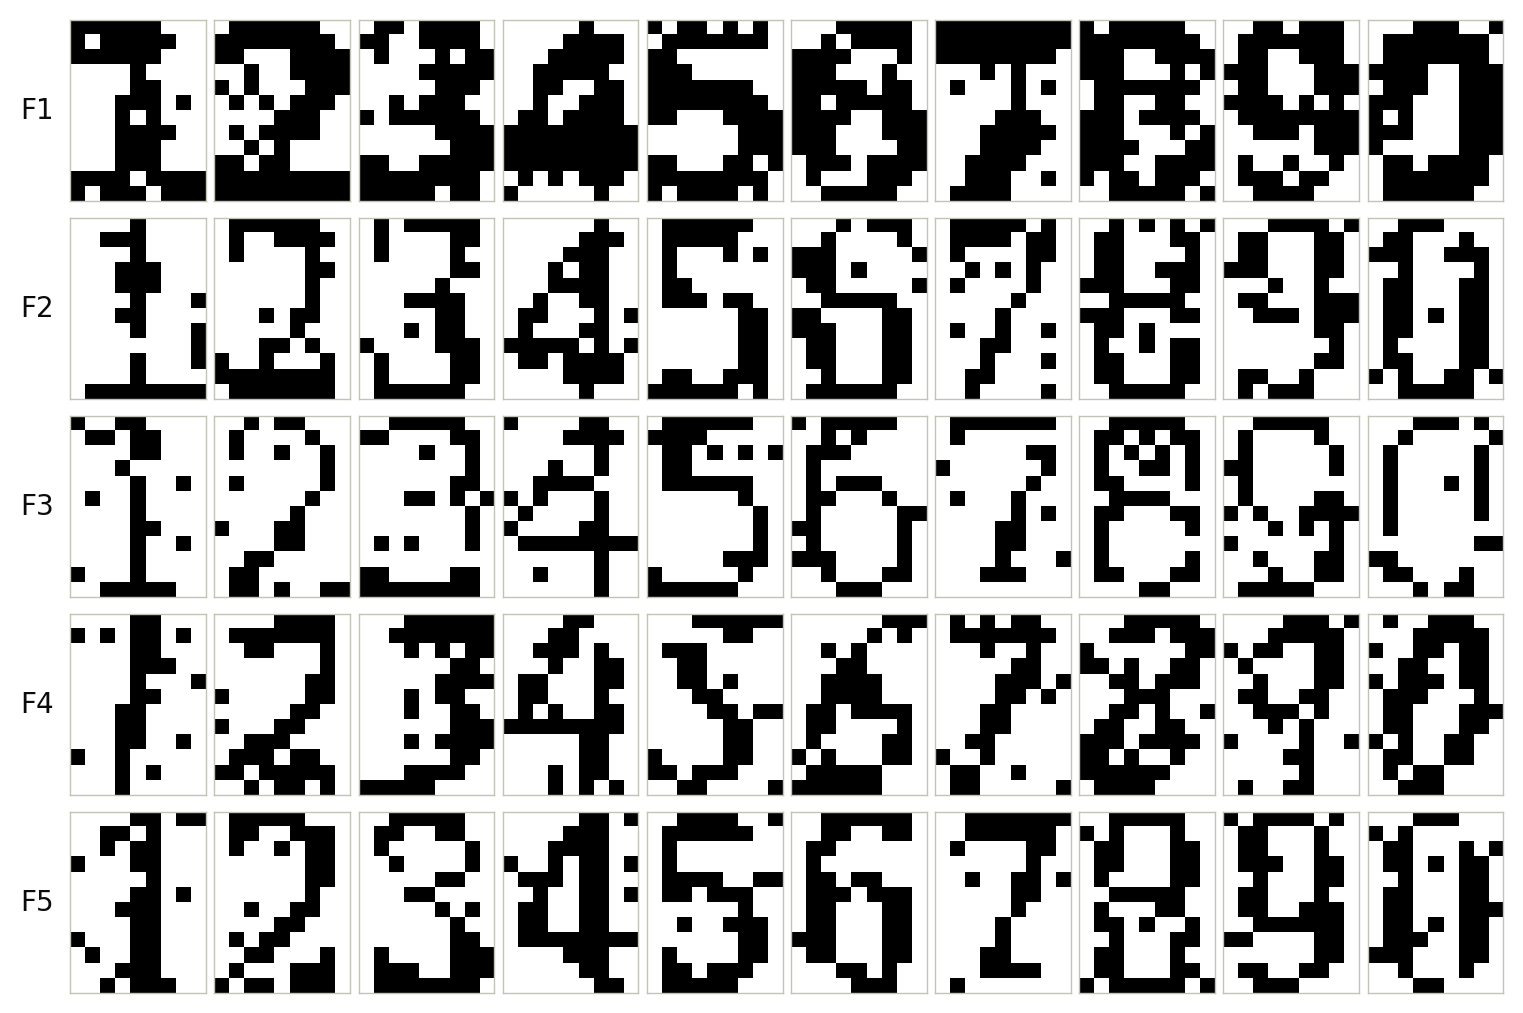

In [9]:
display(Image("figuras/fig_base_ruido10.png", width=700))

### 6.2 Curva de erro e matriz de confusão

Épocas: 144 (sem momento: 663)
Erro inicial: 76.244  |  erro final: 0.0498
Acurácia no treino: 100.0%


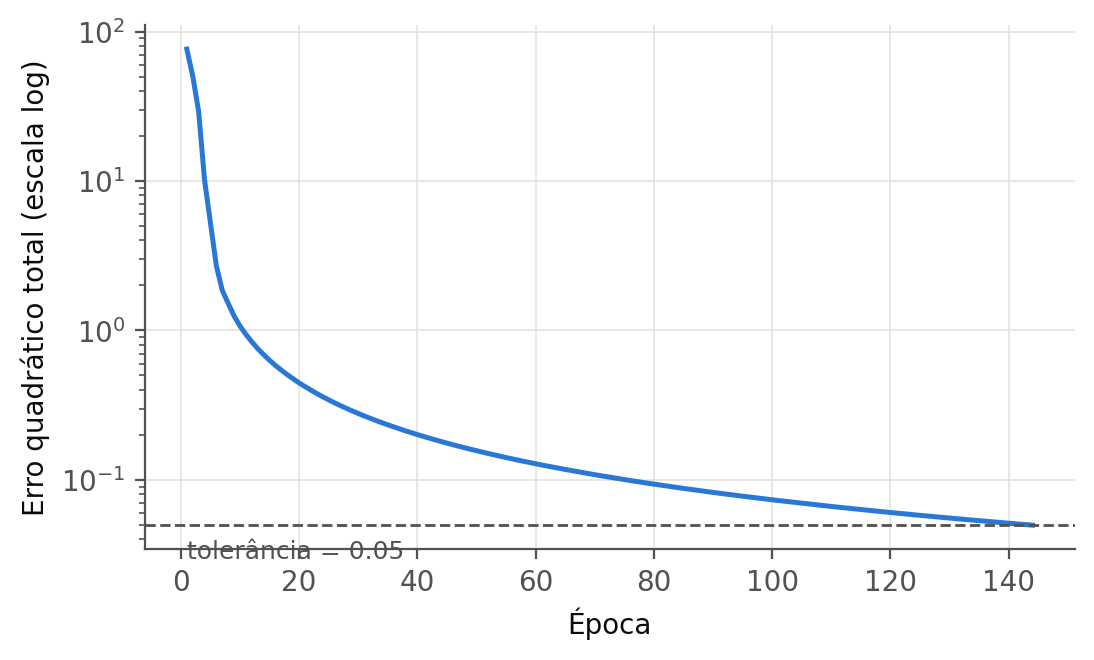

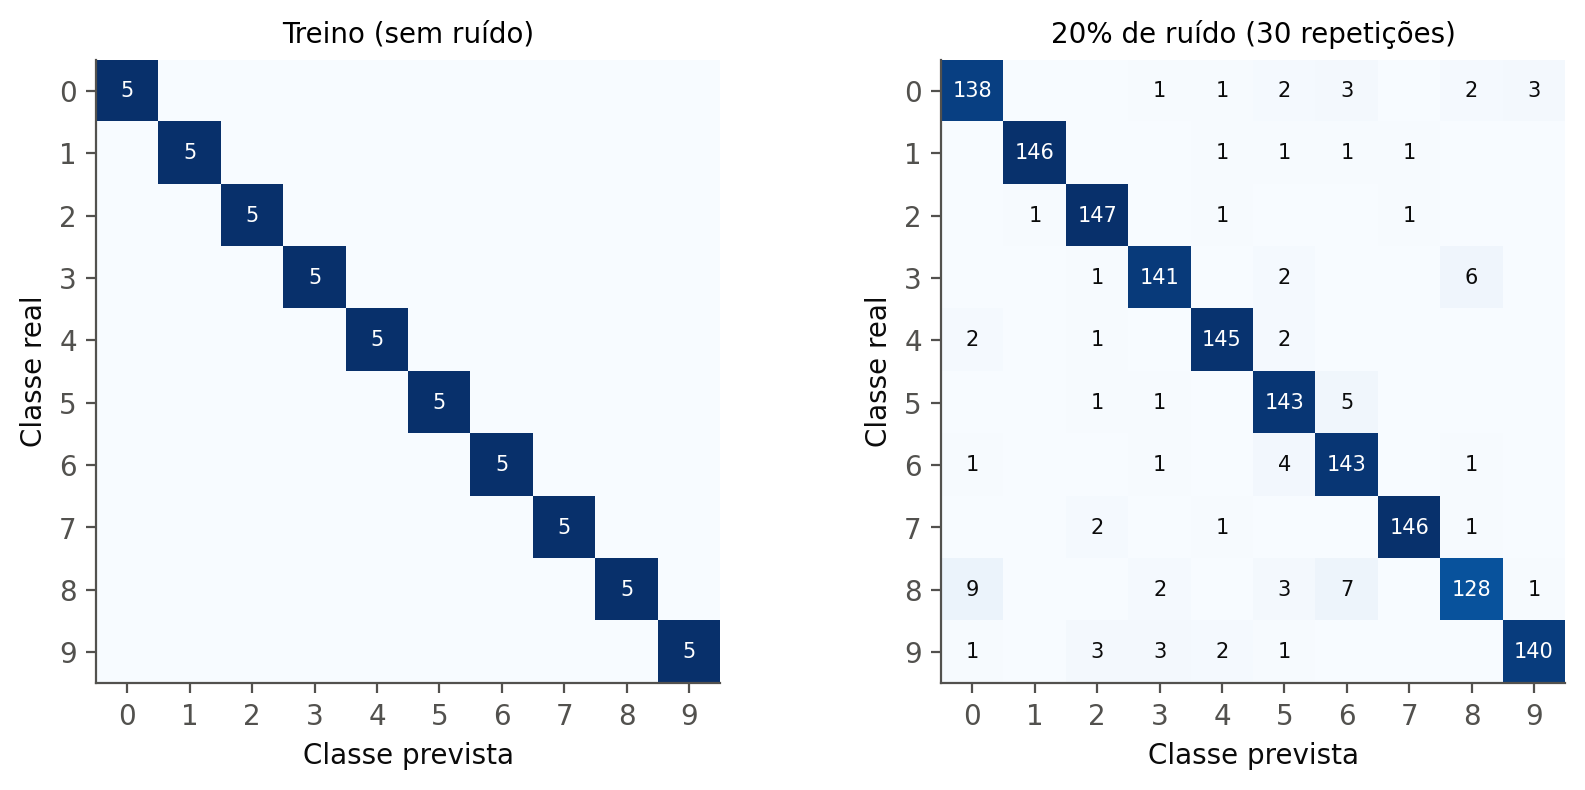

In [10]:
t = resultados["treino"]
print(f"Épocas: {t['epocas']} (sem momento: {t['epocas_sem_momento']})")
print(f"Erro inicial: {t['erro_inicial']:.3f}  |  erro final: {t['erro_final']:.4f}")
print(f"Acurácia no treino: {100 * t['acuracia']:.1f}%")
display(Image("figuras/fig_curva_erro.png", width=600))
display(Image("figuras/fig_confusao.png", width=750))

### 6.3 Robustez a ruído

   0% de ruído: 100.0% ± 0.0
   5% de ruído: 100.0% ± 0.0
  10% de ruído: 100.0% ± 0.0
  15% de ruído:  98.9% ± 1.3
  20% de ruído:  94.5% ± 3.5


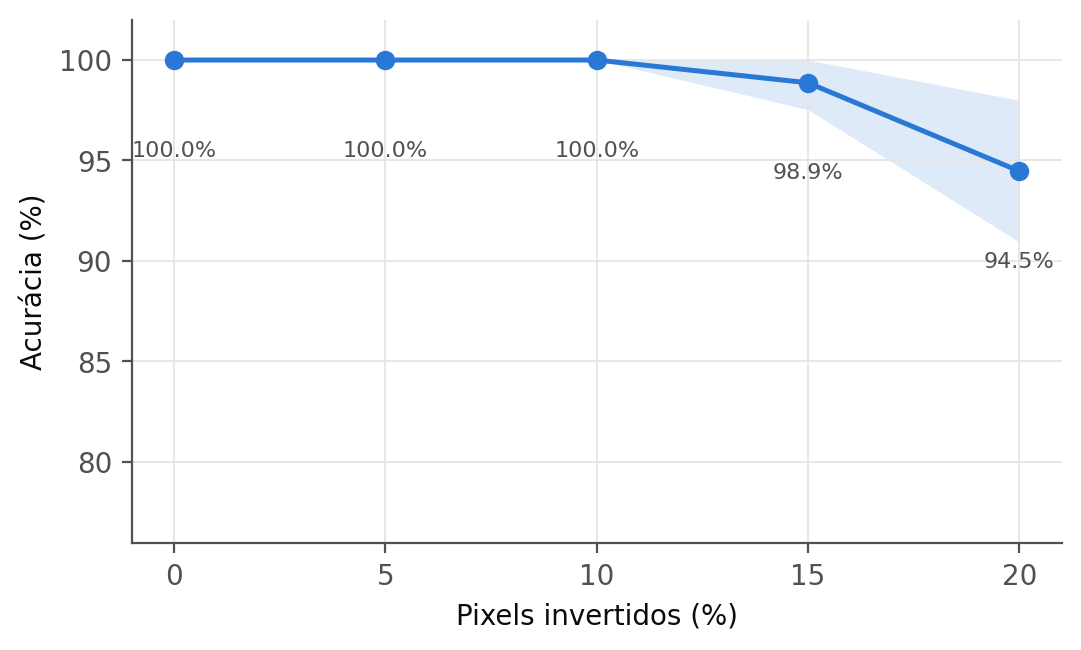

In [11]:
r = resultados["ruido"]
for n, m, d in zip(r["niveis"], r["acuracia_media"], r["acuracia_desvio"]):
    print(f"{100 * n:4.0f}% de ruído: {100 * m:5.1f}% ± {100 * d:.1f}")
display(Image("figuras/fig_ruido.png", width=600))

### 6.4 Generalização entre fontes (*leave-one-font-out*)

In [12]:
print(f"{'Fonte de teste':<46s}{'Acurácia':>12s}   Erros (semente principal)")
for r in resultados["leave_one_font_out"]:
    print(f"{r['fonte_teste']:<46s}{100 * r['acuracia_media']:>9.1f}% ±{100 * r['acuracia_desvio']:4.1f}   "
          f"{', '.join(r['erros_semente_principal']) or '-'}")
print(f"Média geral: {100 * resultados['leave_one_font_out_media_geral']:.1f}%")

Fonte de teste                                    Acurácia   Erros (semente principal)
Sem serifa negrito (DejaVu Sans Bold)              94.0% ± 8.0   -
Serifada regular (Liberation Serif)               100.0% ± 0.0   -
Sem serifa fina (DejaVu Sans ExtraLight)          100.0% ± 0.0   -
Manuscrita/cursiva (Kalam)                         62.0% ± 7.5   4->9, 5->7, 6->8
Serifada condensada (DejaVu Serif Condensed)      100.0% ± 0.0   -
Média geral: 91.2%


### 6.5 Sensibilidade ao número de neurônios ocultos

In [13]:
print(f"{'Ocultos':>8s}{'Épocas':>12s}{'Convergiu':>11s}{'Acc 10% ruído':>16s}")
for r in resultados["sensibilidade_ocultos"]:
    print(f"{r['n_ocultos']:>8d}{r['epocas_media']:>12.1f}{r['convergiu']:>8d}/5{100 * r['acuracia_ruido10_media']:>15.1f}%")

 Ocultos      Épocas  Convergiu   Acc 10% ruído
       5      3469.0       2/5           85.0%
      10       330.6       5/5           99.2%
      20       144.6       5/5           99.9%
      40        81.4       5/5           99.9%


## 7. Discussão

- **Convergência.** Com a inicialização em $U(-0{,}1;\,0{,}1)$, $\alpha = 0{,}01$ e momento $0{,}8$, a rede de 20 neurônios ocultos atinge a tolerância em poucas centenas de épocas, e o momento reduz bastante o número de épocas em relação ao gradiente puro (valores acima).
- **Ruído.** A rede memoriza os 50 padrões e mantém acurácia alta até cerca de 10% de pixels invertidos; a queda aparece a partir de 15–20%, e as confusões se concentram em pares com traços em comum (8, 0, 6, 5, 3).
- **Generalização entre fontes.** É o teste mais exigente: com só quatro exemplos por classe, as fontes cujo desenho difere das demais (a manuscrita e a negrito) são as mais difíceis de reconhecer quando ficam fora do treino; as serifadas e a fina são bem reconhecidas porque são parecidas entre si na grade 12×9.
- **Neurônios ocultos.** Com 5 neurônios a rede tem dificuldade para convergir; de 10 em diante converge sempre, e mais neurônios reduzem as épocas sem ganho relevante de robustez.

Os números exatos estão em `figuras/resultados.json` e são os mesmos citados no relatório.